In [1]:
import numpy as np
import pandas as pd
import astropy.units as u

from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy.io import fits
from astropy.wcs import WCS
from regions import Regions

### Generate and clean the Mawatari catalog

In [2]:
# ## Generate the Mawatari Katalog from the .txt

# import os
# import numpy as np

# from astropy.table import Table
# from astropy.io import ascii

# dir = "../data"
# file = "catalog.txt"

# catalog_file = os.path.join(dir, file)

# data = ascii.read(
#     catalog_file,
#     format="fixed_width_no_header",
#     col_starts=(0, 29, 40, 49, 56, 58, 70, 78, 85),
#     names=["Name", "RA", "DEC", "z", "q_zspec", "r_zspec", "Object", "AGN", "r_AGN"],
#     data_start=107
# )

# data.remove_column("q_zspec")
# data.remove_column("r_zspec")
# data.remove_column("AGN")
# data.remove_column("r_AGN")
# mask = (data["Object"] == "LAE") | (data["Object"] == "LAB")
# data = data[mask]
# mask_z = ~np.isnan(data["z"].astype(float))
# data=data[mask_z]
# data.write("../fits/catalogs/Mawatari_raw.fits", overwrite=True)

In [3]:
# from astropy.table import Table
# from astropy.io import fits
# from astropy.wcs import WCS
# from astropy.coordinates import SkyCoord
# from regions import Regions
# import astropy.units as u
# import numpy as np

# mawatari = Table.read("../fits/catalogs/Mawatari_raw.fits")

# cube = "../fits/cube.fits"
# with fits.open(cube) as f:
#     wcs = WCS(f[0].header).celestial

# coords = SkyCoord(
#     ra=mawatari["RA"] * u.deg,
#     dec=mawatari["DEC"] * u.deg,
#     frame="fk5"
# )

# regions = Regions.read("../regions/fov.reg", format="ds9")

# for r in regions:
#     print(repr(r.meta.get("include")))

# mask = np.zeros(len(coords), dtype=bool)
# mask_e = np.zeros(len(coords), dtype=bool)

# for r in regions:
#     include = r.meta.get("include")
#     if include:
#         mask |= r.contains(coords, wcs)
#     else:
#         mask_e |= r.contains(coords, wcs)

# mask_ = mask_e & mask
# mawatari = mawatari[mask_]

### Matching the Mawatari sources in our FoV with the HSC Image and adding the magnitude

In [4]:
# hsc = Table.read("~/Desktop/mpe/fits/catalogs/HSC.fits")

# mawa = SkyCoord(ra=mawatari["RA"] * u.deg,
#                 dec=mawatari["DEC"] * u.deg)

# hsc_ = SkyCoord(ra=hsc["ra"] * u.deg,
#                 dec=hsc["dec"] * u.deg)

# idx, sep2d, _ = mawa.match_to_catalog_sky(hsc_)
# mask = sep2d < 2 * u.arcsec

# g_mag_col = np.full(len(mawatari), np.nan)

# g_mag_col[mask] = hsc["g_cmodel_mag"][idx[mask]]

# mawatari["g_mag"] = g_mag_cols

# mawatari.write("~/Desktop/mpe/fits/catalogs/mawatari.fits", overwrite=True)

### Matching the Mawatari catalog to the automatically generated catalog form Hetdex data

In [10]:
from functions import crossmatch_and_merge_catalogs as crossmatch_catalogs

mawa = "../fits/catalogs/mawatari.fits"
auto = "../Random_Forest/combined_manual_vdfi_rfscored.fits"

out = "../fits/catalogs/mawatari_matched.fits"
out_ = "../fits/catalogs/combined_manual_vdfi_matched.fits"

crossmatch_catalogs(mawa, out, auto, max_delta_z=0.5, ref_prefix="vdfi_")
crossmatch_catalogs(auto, out_, mawa, max_delta_z=0.5,
                    ra_col_primary="ra_vdfi", ra_col_ref="RA",
                    dec_col_primary="dec_vdfi", dec_col_ref="DEC",
                    z_col_primary="z_vdfi", z_col_ref="z", ref_prefix="mawa_")

Matches gefunden und gemerged: 89 / 168
Referenzquellen ohne Match:    15364
Matches gefunden und gemerged: 90 / 15453
Referenzquellen ohne Match:    78


### Get the equvalent width for each source as well as the probability

### Run the random Forrest to see the correlation of sources that were not found in the manual catalog

In [7]:
!python ../Random_Forest/random_forest_classifier.py -i ../fits/catalogs/mawatari_matched.fits --output-plot ../plots/random_forest_classifier_.png  --output-fits ./mawatari_rfscored.fits --label "matched_in_reference"

Reading ../fits/catalogs/mawatari_matched.fits …
  168 rows, 658 columns
  Positives: 89  Negatives: 79  (53.0% positive)
Building feature matrix …
  600 features, matrix shape: (168, 600)
Training Random Forest (300 trees, 5-fold CV) …
  CV AUC-ROC : 1.0000
  CV AUC-PR  : 1.0000

Top 10 features:
  ref_ref_ref_ref_ref_ref_ref_ref_object_id_hsc 0.0386
  ref_ref_ref_ref_ymax_vdfi                0.0319
  ref_matched_in_reference                 0.0285
  ref_ref_ref_ref_ref_ref_object_id_hsc    0.0272
  ref_ref_ref_ref_zmax_vdfi                0.0250
  ref_ref_ymax_vdfi                        0.0249
  ref_ref_ref_ref_ref_ref_ref_ref_xmax_vdfi 0.0233
  ref_ref_ref_ref_ref_ref_ref_ref_ref_matched_in_reference 0.0233
  ref_ref_ref_ref_ref_ref_matched_in_reference 0.0233
  ref_ref_ref_ref_ref_ref_ymin_vdfi        0.0233

Operating points:
  High recall (95%) : thresh=0.963  prec=1.000  N=85
  Best F1           : thresh=0.853  prec=1.000  rec=1.000  F1=1.000  N=88
  High prec  (90%)  : thresh=

### Extract the segments for the missing sources

In [ ]:
import numpy as np
from astropy.table import Table
from astropy.io import fits
from astropy.wcs import WCS
from scipy import stats

CATALOG_PATH = "../fits/catalogs/mawatari_mit_cnn_score.fits"
CUBE_PATH    = "/Volumes/EXTERN/MPE/fits/segmentierung/combined_cube.fits"
OUT_PATH     = "../fits/catalogs/mawatari_final.fits"

RA_COL  = "RA"
DEC_COL = "DEC"
Z_COL   = "z"   # Redshift

LYA = 1215.67  # Å
R = 3           # -> ~10x10x10 Fenster

# laden
tbl = Table.read(CATALOG_PATH)
hdul = fits.open(CUBE_PATH)
cube = hdul[0].data          # (nz, ny, nx)
wcs  = WCS(hdul[0].header)

# Redshift -> Wellenlänge
wave = LYA * (1.0 + tbl[Z_COL])

# Welt -> Pixel
x, y, z = wcs.all_world2pix(
    tbl[RA_COL],
    tbl[DEC_COL],
    wave,
    0
)

# runden
xi = np.round(x).astype(int)
yi = np.round(y).astype(int)
zi = np.round(z).astype(int)

# bounds global
nz, ny, nx = cube.shape
valid = (
    (0 <= xi) & (xi < nx) &
    (0 <= yi) & (yi < ny) &
    (0 <= zi) & (zi < nz)
)

values = np.full(len(tbl), np.nan)

# 3D Fenster
for i in range(len(tbl)):
    if not valid[i]:
        continue

    x0, y0, z0 = xi[i], yi[i], zi[i]

    x1, x2 = max(0, x0 - R), min(nx, x0 + R)
    y1, y2 = max(0, y0 - R), min(ny, y0 + R)
    z1, z2 = max(0, z0 - R), min(nz, z0 + R)

    subcube = cube[z1:z2, y1:y2, x1:x2]

    if subcube.size > 0:
        values[i] = int(np.nanmax(subcube))

# anhängen + speichern
tbl["cube_value"] = values
tbl.write(OUT_PATH, overwrite=True)

hdul.close()
#tbl

### Looking at the Lyman alpha fluxes

In [9]:
# from astropy.table import Table

# tbl = Table.read("/Users/bene/Desktop/mpe/fits/catalogs/katalog_mit_cnn_score.fits")
# mask_m = tbl["manually_detected"] == False
# mask_mag = tbl["rf_score"] < 0.2 #tbl["g_cmodel_mag_hsc"] > 27.5
# mask = mask_m & mask_mag
# tbl = tbl[mask]
# tbl.write("neue_negative.fits", overwrite=True)

### Using the CNN extracted catalog from the cube
Extracting the segments for the found sources. Those witout a segment will beused as negatives for training.

In [10]:
#Table.read("/Users/bene/Desktop/mpe/fits/catalogs/kandidaten_cube_search.fits")

In [11]:
# from astropy.table import Table
# from astropy.io import fits
# from astropy.wcs import WCS
# from scipy import stats

# CATALOG_PATH = "/Users/bene/Desktop/mpe/fits/catalogs/kandidaten_cube_search.fits"
# CUBE_PATH    = "/Volumes/EXTERN/MPE/fits/segmentierung/combined_cube.fits"
# OUT_PATH     = "../fits/catalogs/negative_examples.fits"

# RA_COL  = "RA"
# DEC_COL = "DEC"
# Z_COL   = "REDSHIFT"   # Redshift

# LYA = 1215.67  # Å
# R = 2           # -> ~10x10x10 Fenster

# # laden
# tbl = Table.read(CATALOG_PATH)
# hdul = fits.open(CUBE_PATH)
# cube = hdul[0].data          # (nz, ny, nx)
# wcs  = WCS(hdul[0].header)

# # Redshift -> Wellenlänge
# wave = LYA * (1.0 + tbl[Z_COL])

# # Welt -> Pixel
# x, y, z = wcs.all_world2pix(
#     tbl[RA_COL],
#     tbl[DEC_COL],
#     wave,
#     0
# )

# # runden
# xi = np.round(x).astype(int)
# yi = np.round(y).astype(int)
# zi = np.round(z).astype(int)

# # bounds global
# nz, ny, nx = cube.shape
# valid = (
#     (0 <= xi) & (xi < nx) &
#     (0 <= yi) & (yi < ny) &
#     (0 <= zi) & (zi < nz)
# )

# values = np.full(len(tbl), np.nan)

# # 3D Fenster
# for i in range(len(tbl)):
#     if not valid[i]:
#         continue

#     x0, y0, z0 = xi[i], yi[i], zi[i]

#     x1, x2 = max(0, x0 - R), min(nx, x0 + R)
#     y1, y2 = max(0, y0 - R), min(ny, y0 + R)
#     z1, z2 = max(0, z0 - R), min(nz, z0 + R)

#     subcube = cube[z1:z2, y1:y2, x1:x2]

#     if subcube.size > 0:
#         values[i] = int(np.nanmax(subcube))

# # anhängen + speichern
# tbl["cube_value"] = values
# #tbl.write(CATALOG_PATH, overwrite=True)

# hdul.close()
# tbl
# mask = tbl["cube_value"] <= 0
# tbl = tbl[mask]
# tbl.write("neue_negative.fits", overwrite=True)
# tbl

In [12]:
# tbl = Table.read("../Random_Forrest/combined_manual_vdfi_rfscored.fits")

# mask = tbl["rf_score"] < 0.2
# tbl = tbl[mask]
# tbl_new = Table([tbl["ra_vdfi"], tbl["dec_vdfi"], tbl["z_vdfi"]], names=("RA", "DEC", "z"))
# tbl_new.write("neue_negative.fits", overwrite=True)

  Wende 1 Filter an:
  Filter matched_in_reference == False                → 79 / 168
  → 79 Objekte nach Filterung.
Lade Cube: /Volumes/EXTERN/MPE/fits/cube/cube.fits
  Shape: (1036, 2478, 2260)
  Erzeuge 79 Cutouts ...


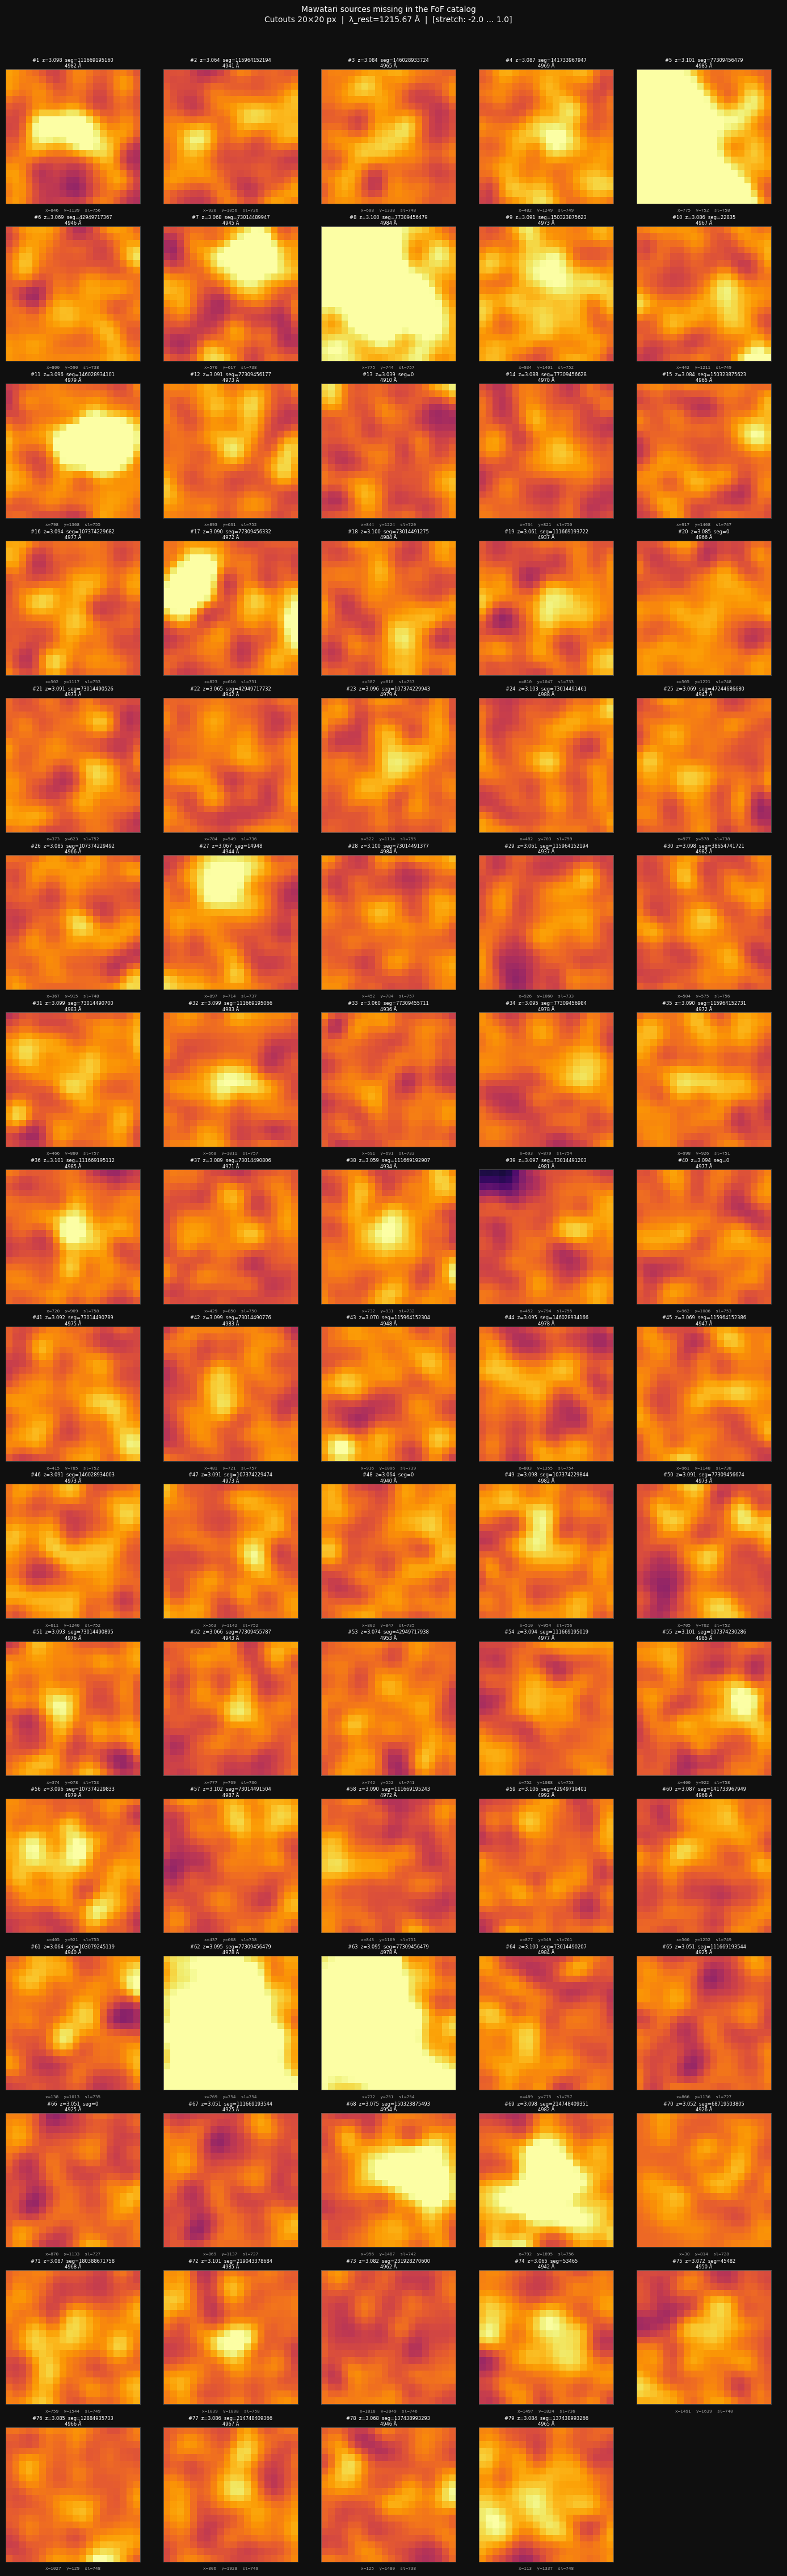

  Gespeichert: ../plots/missing_mawatari_sources.pdf


In [13]:
from functions import plot_cutout_grid

cube = "/Volumes/EXTERN/MPE/fits/cube/cube.fits"
segment = "/Volumes/EXTERN/MPE/fits/segmentierung/combined_cube.fits"

catalog = Table.read("../fits/catalogs/mawatari_matched.fits")

plot_cutout_grid(
    catalog,
    cube,
    "../plots/missing_mawatari_sources.pdf",
    col_seg         = "cube_value",
    filters         = [{"column": "matched_in_reference", "op": "==", "value": False}],
    use_fixed_stretch = True,
    vmin_fixed      = -2.0,
    vmax_fixed      =  1.0,
    cmap            = "inferno",
    title           = "Mawatari sources missing in the FoF catalog"
)

In [14]:
from astropy.table import Table

cat = Table.read("../Random_Forest/combined_manual_vdfi_rfscored.fits")
cat

z_mask = (cat["z_vdfi"] > 2.6) & (cat["z_vdfi"] < 2.8) & (cat["P_of_LAE"] > 0.7)
cat = cat[z_mask]
print(f"sigma_x: {min(cat["xsigma_vdfi"])}, {max(cat["xsigma_vdfi"])}")
print(f"sigma_y: {min(cat["ysigma_vdfi"])}, {max(cat["ysigma_vdfi"])}")
print(f"sigma_z: {min(cat["zsigma_vdfi"])}, {max(cat["zsigma_vdfi"])}")
print(f"flux: {min(cat["summed_flux_vdfi"])}, {max(cat["summed_flux_vdfi"])}")

sigma_x: 0.0, 27.43335157749243
sigma_y: 0.0, 42.29075783962617
sigma_z: 0.0, 45.49569711674121
flux: 0.007502717897295952, 528.091862719506


1740


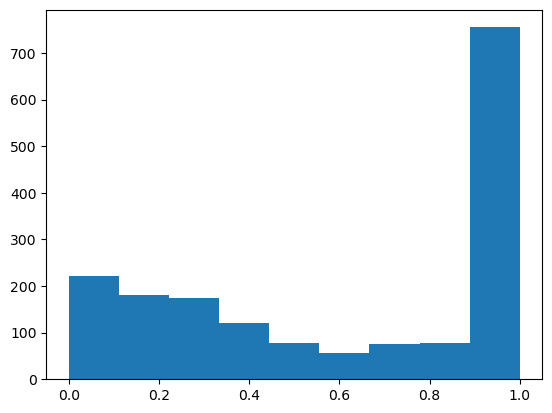

In [15]:
from astropy.table import Table
import numpy as np

#tbl = Table.read("../fits/catalogs/mawatari_in_auto.fits")
#mask = tbl["P_of_LAE"] < 0.4
#tbl[mask]
tbl = Table.read("../Random_Forest/combined_manual_vdfi_rfscored.fits")
mask = tbl["rf_score"] > 0.7
tbl = tbl[mask]
import matplotlib.pyplot as plt
bins = np.linspace(0,1,10)
plt.hist(tbl["P_of_LAE"], bins=bins)
print(len(tbl))
plt.savefig("../plots/p_of_lae.pdf")

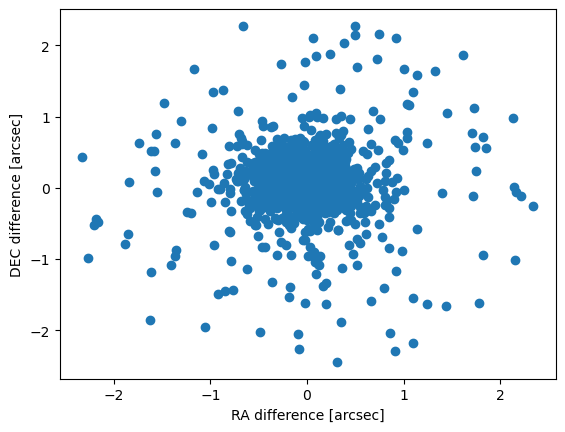

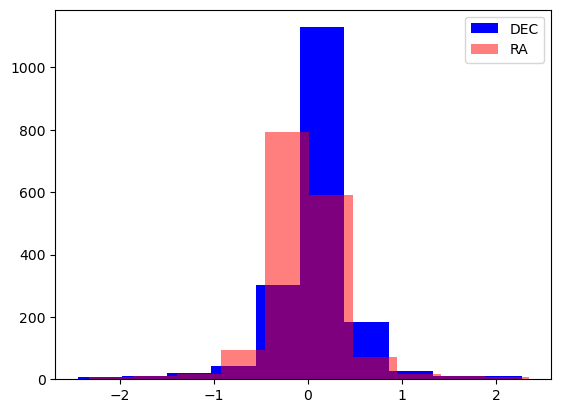

In [16]:
dec_diff = (tbl["dec_vdfi"] - tbl["dec_hsc"]) * 3600
ra_diff = (tbl["ra_vdfi"] - tbl["ra_hsc"]) * 3600

plt.scatter(ra_diff, dec_diff)
plt.xlabel("RA difference [arcsec]")
plt.ylabel("DEC difference [arcsec]")
plt.savefig("../plots/source_match_offset_arcsec.pdf")
plt.show()
plt.hist(dec_diff, color="b", label="DEC")
plt.hist(ra_diff, color="r", alpha=0.5, label="RA")
plt.legend()
plt.savefig("../plots/source_match_offset_hist.pdf")
plt.show()